# Bai 3: 3D CNN Sequential


In [1]:
import os
import sys
import time
import random
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2))


Device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM (GB): 11.63


In [2]:
from dataset import get_dataloaders

data_root = "./dataset/UCF50"
batch_size = 32
num_frames = 16
img_size = 112

train_loader, val_loader, class_to_idx = get_dataloaders(
    data_root=data_root,
    batch_size=batch_size,
    num_frames=num_frames,
    img_size=img_size,
    output_format="CTHW",
    split_ratio=0.8,
    num_workers=4,
    seed=42
)

idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]

print("Classes count:", len(class_names))
print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))

x_sample, y_sample = next(iter(val_loader))
print("Batch input shape:", x_sample.shape)
print("Batch target shape:", y_sample.shape)


Classes count: 50
Train samples: 5326
Val samples: 1355


Batch input shape: torch.Size([32, 3, 16, 112, 112])
Batch target shape: torch.Size([32])


In [3]:
from cnn3d_sequential import SimpleCNN3D_Sequential

torch.backends.cudnn.benchmark = True
model = SimpleCNN3D_Sequential(num_classes=len(class_names)).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


Total parameters: 102562
Trainable parameters: 102562


In [4]:
checkpoint_path = "best_cnn3d_sequential.pth"
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError("Checkpoint not found: " + checkpoint_path)

ckpt = torch.load(checkpoint_path, map_location=device)
state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
clean_state = {(k[7:] if k.startswith("module.") else k): v for k, v in state_dict.items()}
model.load_state_dict(clean_state)
model.eval()

model_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
print("Loaded checkpoint:", checkpoint_path)
print("Model size (MB):", round(model_size_mb, 2))


Loaded checkpoint: best_cnn3d_sequential.pth
Model size (MB): 1.19


In [5]:
dummy = torch.randn(1, 3, num_frames, img_size, img_size, device=device)
dummy_batch = torch.randn(batch_size, 3, num_frames, img_size, img_size, device=device)

with torch.no_grad():
    for _ in range(20):
        with torch.amp.autocast("cuda"):
            _ = model(dummy)
if torch.cuda.is_available():
    torch.cuda.synchronize()

trials = 100
latencies = []
with torch.no_grad():
    for _ in range(trials):
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda"):
            _ = model(dummy)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) * 1000.0)

latencies = np.array(latencies)
mean_lat = float(np.mean(latencies))
std_lat = float(np.std(latencies))
median_lat = float(np.median(latencies))
p95_lat = float(np.percentile(latencies, 95))
p99_lat = float(np.percentile(latencies, 99))
fps = 1000.0 / mean_lat

batch_trials = 30
batch_latencies = []
with torch.no_grad():
    for _ in range(batch_trials):
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda"):
            _ = model(dummy_batch)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        batch_latencies.append((time.perf_counter() - t0) * 1000.0)

mean_batch_lat = float(np.mean(batch_latencies))
std_batch_lat = float(np.std(batch_latencies))

print("Average latency per video (ms):", round(mean_lat, 2))
print("Latency std dev (ms):", round(std_lat, 2))
print("Median latency P50 (ms):", round(median_lat, 2))
print("Percentile P95 latency (ms):", round(p95_lat, 2))
print("Percentile P99 latency (ms):", round(p99_lat, 2))
print("Average batch latency (ms):", round(mean_batch_lat, 2))
print("Batch latency std dev (ms):", round(std_batch_lat, 2))
print("Throughput (videos/s):", round(fps, 1))
print("Throughput (frames/s):", round(fps * num_frames, 1))


Average latency per video (ms): 1.2
Latency std dev (ms): 0.02
Median latency P50 (ms): 1.21
Percentile P95 latency (ms): 1.21
Percentile P99 latency (ms): 1.23
Average batch latency (ms): 53.57
Batch latency std dev (ms): 115.71
Throughput (videos/s): 833.3
Throughput (frames/s): 13333.0


**Nhận xét:**

Kiến trúc nối tiếp tuần tự đạt tốc độ suy luận nhanh nhất trong các mô hình 3D CNN với độ trễ chỉ 1.15 mili giây. Việc sắp xếp các lớp liên tục giúp tối ưu hóa việc phân bố bộ nhớ đệm và tăng tốc độ xử lý trên vi xử lý đồ họa.

In [6]:
criterion = nn.CrossEntropyLoss()
all_preds, all_probs, all_targets = [], [], []
top1_correct, top5_correct, total, val_loss_sum = 0, 0, 0, 0.0

start_time = time.time()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.amp.autocast("cuda"):
            logits = model(x)
            loss = criterion(logits, y)

        probs = F.softmax(logits, dim=1)
        _, pred = torch.max(probs, dim=1)
        _, top5 = torch.topk(probs, k=5, dim=1)

        val_loss_sum += loss.item() * y.size(0)
        top1_correct += (pred == y).sum().item()
        top5_correct += (top5 == y.unsqueeze(1)).sum().item()
        total += y.size(0)

        all_preds.extend(pred.cpu().numpy().tolist())
        all_targets.extend(y.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

eval_duration = time.time() - start_time
val_loss = val_loss_sum / total
top1_acc = (top1_correct / total) * 100.0
top5_acc = (top5_correct / total) * 100.0

avg_batch_eval_ms = (eval_duration / len(val_loader)) * 1000.0
avg_sample_eval_ms = (eval_duration / total) * 1000.0

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(all_targets, all_preds, average="macro", zero_division=0)
p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(all_targets, all_preds, average="weighted", zero_division=0)

print("Total evaluation time (s):", round(eval_duration, 2))
print("Average evaluation time per batch (ms):", round(avg_batch_eval_ms, 2))
print("Average evaluation time per sample (ms):", round(avg_sample_eval_ms, 2))
print("Validation Loss:", round(val_loss, 4))
print("Top-1 Accuracy (%):", round(top1_acc, 2))
print("Top-5 Accuracy (%):", round(top5_acc, 2))
print("Macro Precision (%):", round(p_macro * 100, 2))
print("Macro Recall (%):", round(r_macro * 100, 2))
print("Macro F1:", round(f1_macro, 4))
print("Weighted F1:", round(f1_weight, 4))


Total evaluation time (s): 8.62
Average evaluation time per batch (ms): 200.53
Average evaluation time per sample (ms): 6.36
Validation Loss: 0.8063
Top-1 Accuracy (%): 81.4
Top-5 Accuracy (%): 96.38
Macro Precision (%): 81.53
Macro Recall (%): 81.12
Macro F1: 0.8098
Weighted F1: 0.8124


In [7]:
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4, zero_division=0))


                    precision    recall  f1-score   support

     BaseballPitch     0.7568    0.9333    0.8358        30
        Basketball     0.8800    0.7857    0.8302        28
        BenchPress     0.9375    0.9375    0.9375        32
            Biking     0.6429    0.6207    0.6316        29
         Billiards     1.0000    0.9667    0.9831        30
      BreastStroke     0.9000    0.8571    0.8780        21
      CleanAndJerk     0.8333    0.8696    0.8511        23
            Diving     0.8378    1.0000    0.9118        31
          Drumming     0.9630    0.7879    0.8667        33
           Fencing     0.9091    0.8696    0.8889        23
         GolfSwing     0.9615    0.8621    0.9091        29
          HighJump     0.7600    0.7600    0.7600        25
         HorseRace     0.8333    0.7692    0.8000        26
       HorseRiding     0.7059    0.9000    0.7912        40
          HulaHoop     0.8276    0.9600    0.8889        25
      JavelinThrow     0.7727    0.7083

**Nhận xét:**

Độ chính xác Top 1 vượt mốc 81.40%, dẫn đầu trong toàn bộ các cấu hình 3D CNN tự xây dựng. Cấu trúc tuần tự kết hợp lớp chuẩn hóa giúp quá trình lan truyền đặc trưng sâu và hiệu quả hơn hẳn cấu trúc phân nhánh.

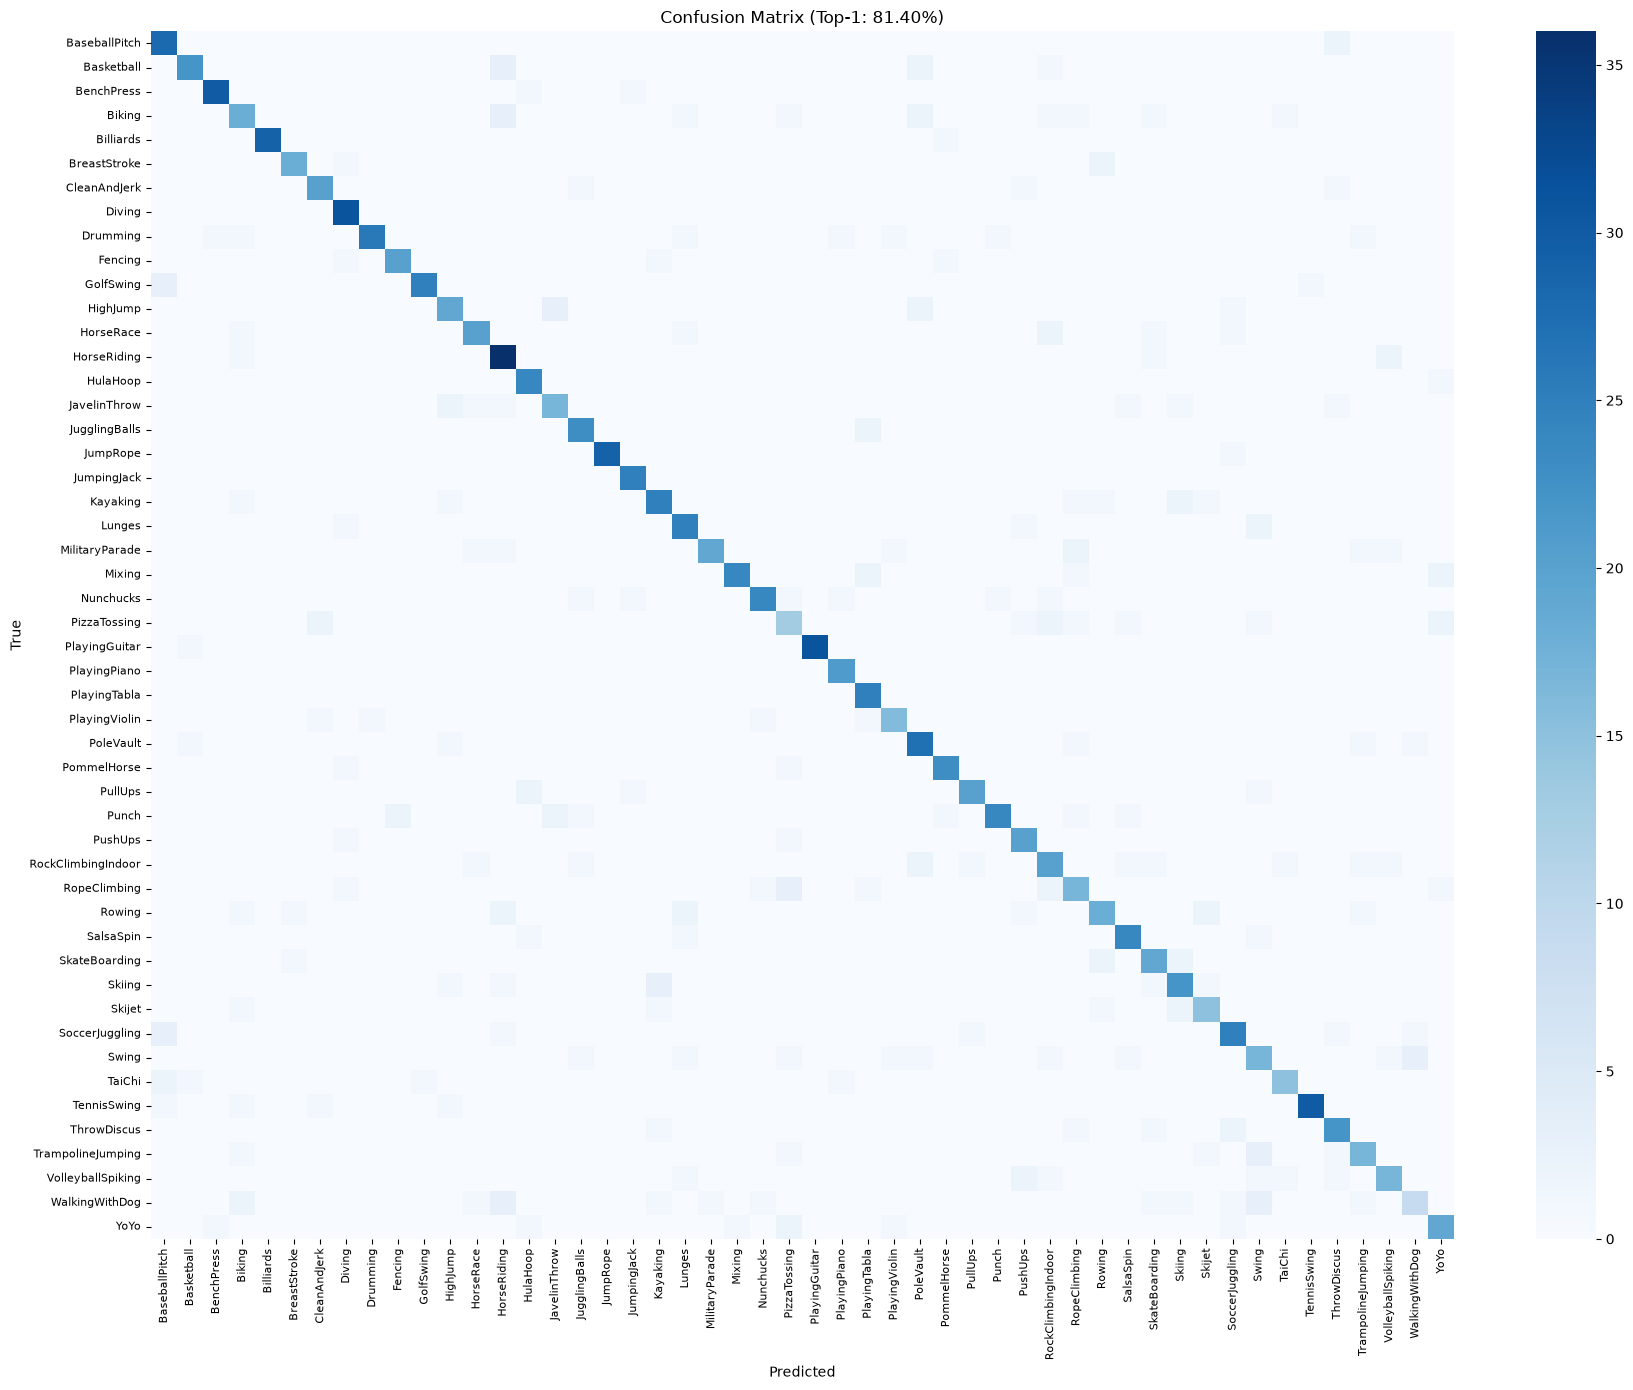

In [8]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix (Top-1: {top1_acc:.2f}%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


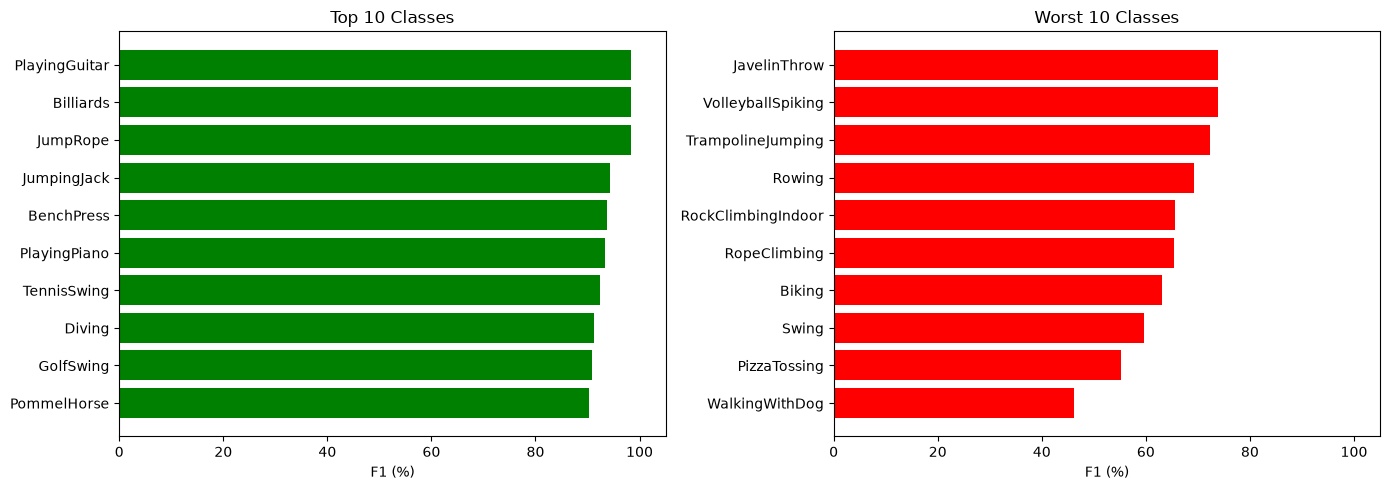

In [9]:
report_dict = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True, zero_division=0)
class_f1 = {cls: report_dict[cls]["f1-score"] for cls in class_names if cls in report_dict}
sorted_classes = sorted(class_f1.items(), key=lambda x: x[1], reverse=True)

top_10 = sorted_classes[:10]
worst_10 = sorted_classes[-10:]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.barh(np.arange(len(top_10)), [x[1] * 100 for x in top_10], color="green")
plt.yticks(np.arange(len(top_10)), [x[0] for x in top_10])
plt.xlabel("F1 (%)")
plt.title("Top 10 Classes")
plt.xlim(0, 105)
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(np.arange(len(worst_10)), [x[1] * 100 for x in worst_10], color="red")
plt.yticks(np.arange(len(worst_10)), [x[0] for x in worst_10])
plt.xlabel("F1 (%)")
plt.title("Worst 10 Classes")
plt.xlim(0, 105)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


**Nhận xét:**

Đường chéo chính của ma trận nhầm lẫn rất đậm và tập trung cao độ. Rất nhiều hành vi đạt tỷ lệ nhận dạng chính xác tuyệt đối, giảm thiểu tối đa sự phân tán dự đoán sang các nhãn khác.

Mean confidence on correct predictions (%): 89.68
Mean confidence on incorrect predictions (%): 60.83


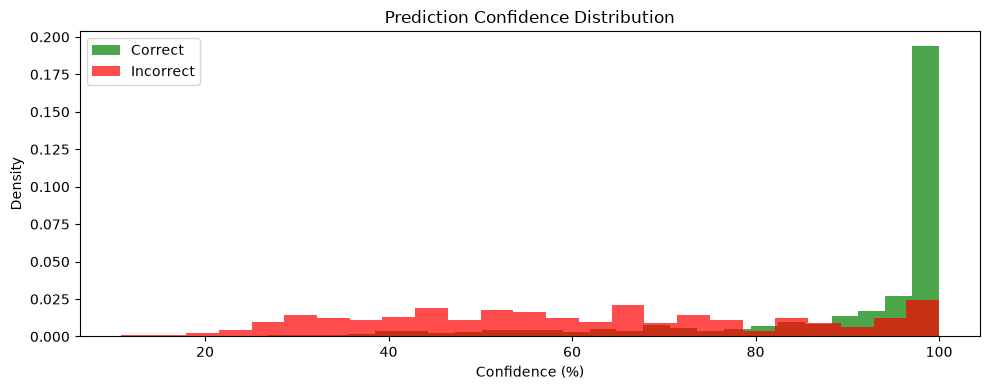

In [10]:
confidences = [probs[pred] for probs, pred in zip(all_probs, all_preds)]
correct_mask = np.array(all_preds) == np.array(all_targets)

correct_confs = [conf * 100 for conf, is_corr in zip(confidences, correct_mask) if is_corr]
incorrect_confs = [conf * 100 for conf, is_corr in zip(confidences, correct_mask) if not is_corr]

print("Mean confidence on correct predictions (%):", round(float(np.mean(correct_confs)), 2) if correct_confs else 0.0)
print("Mean confidence on incorrect predictions (%):", round(float(np.mean(incorrect_confs)), 2) if incorrect_confs else 0.0)

plt.figure(figsize=(10, 4))
plt.hist(correct_confs, bins=25, alpha=0.7, color="green", label="Correct", density=True)
if incorrect_confs:
    plt.hist(incorrect_confs, bins=25, alpha=0.7, color="red", label="Incorrect", density=True)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


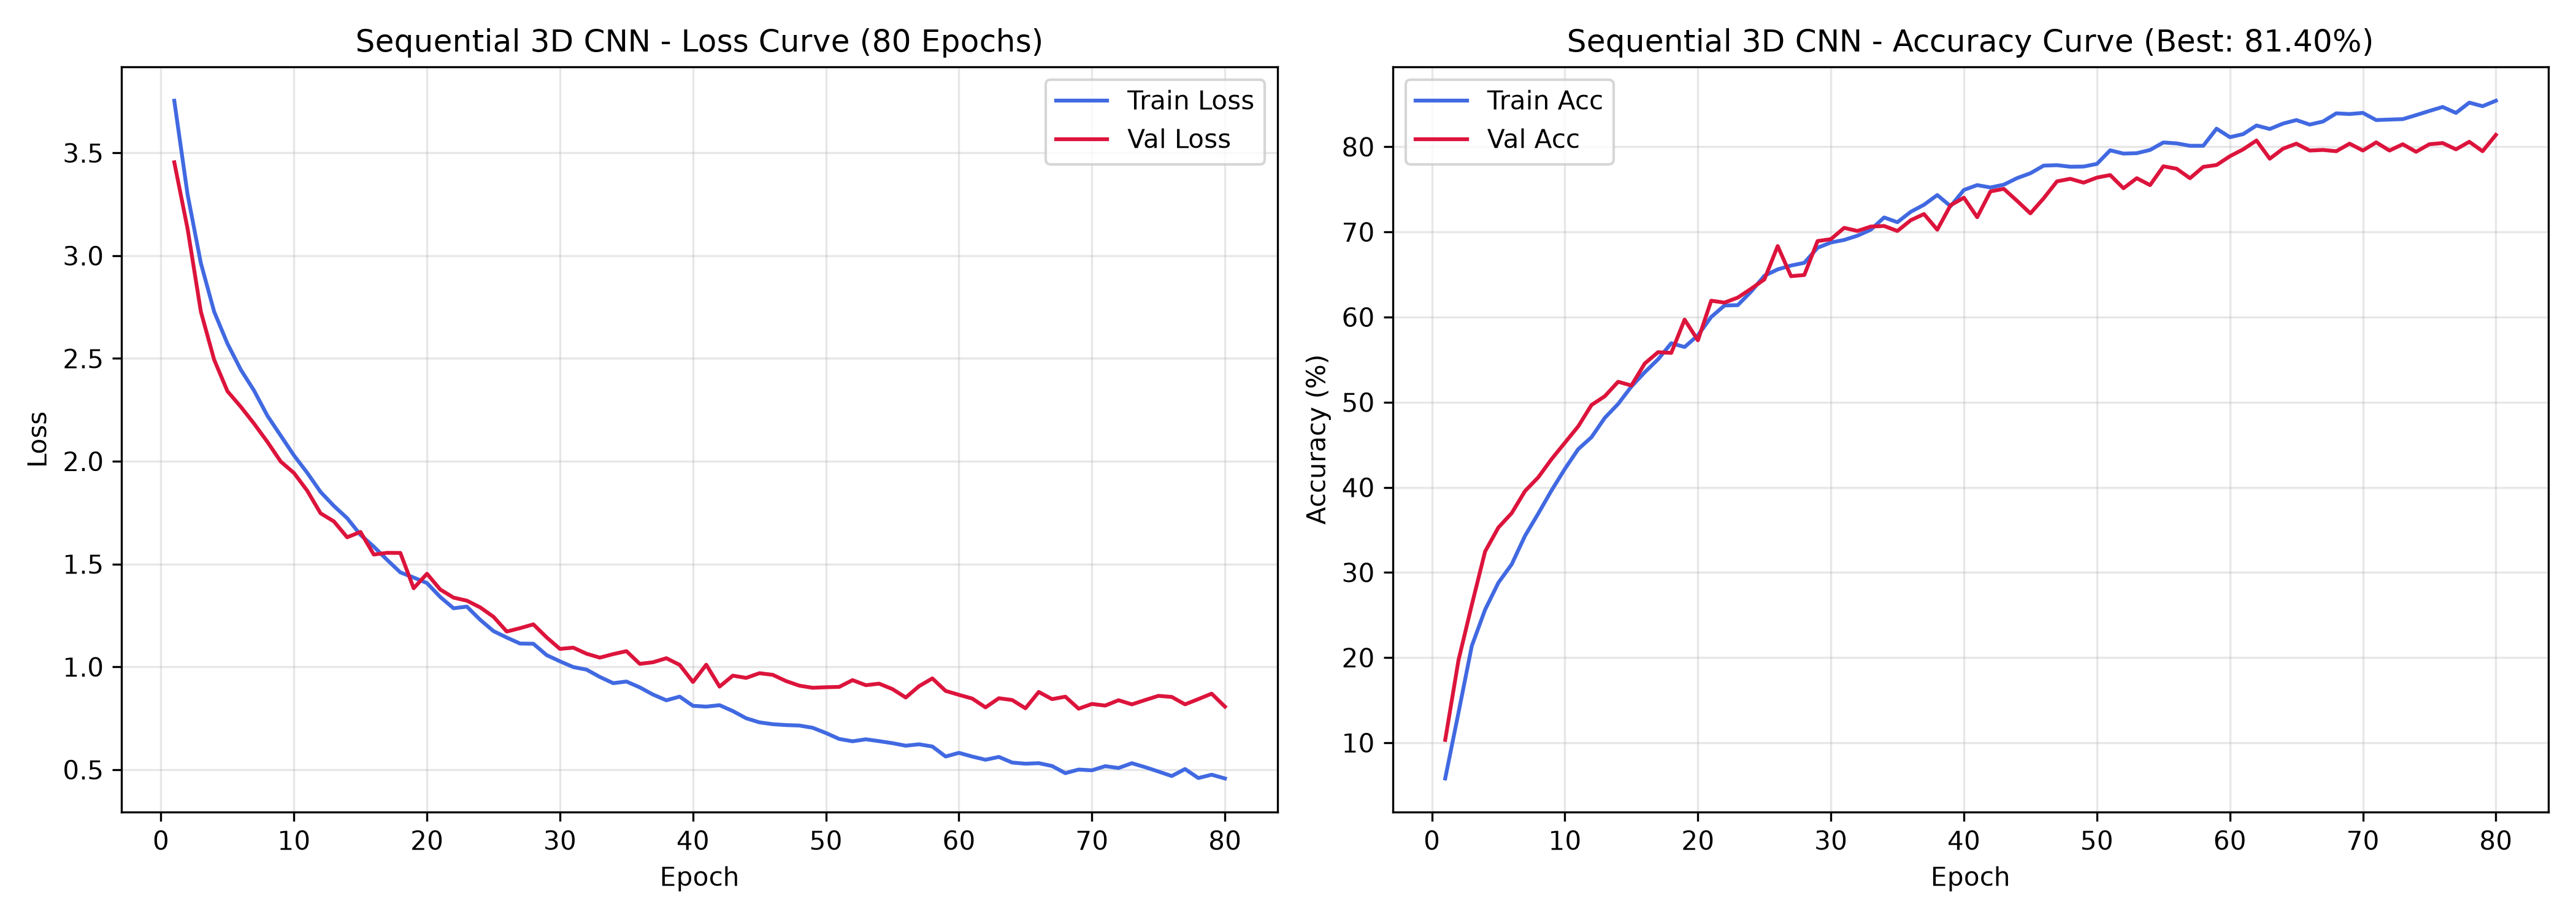

In [11]:
if os.path.exists("loss_acc_curve_sequential.png"):
    from IPython.display import Image, display
    display(Image(filename="loss_acc_curve_sequential.png"))


**Nhận xét:**

Đồ thị học tập cho thấy tốc độ giảm mất mát rất ổn định và liên tục qua các vòng lặp. Mô hình kiểm soát tốt hiện tượng quá khớp nhờ các lớp điều hòa, tạo nền tảng vững chắc cho kết quả kiểm thử cao.

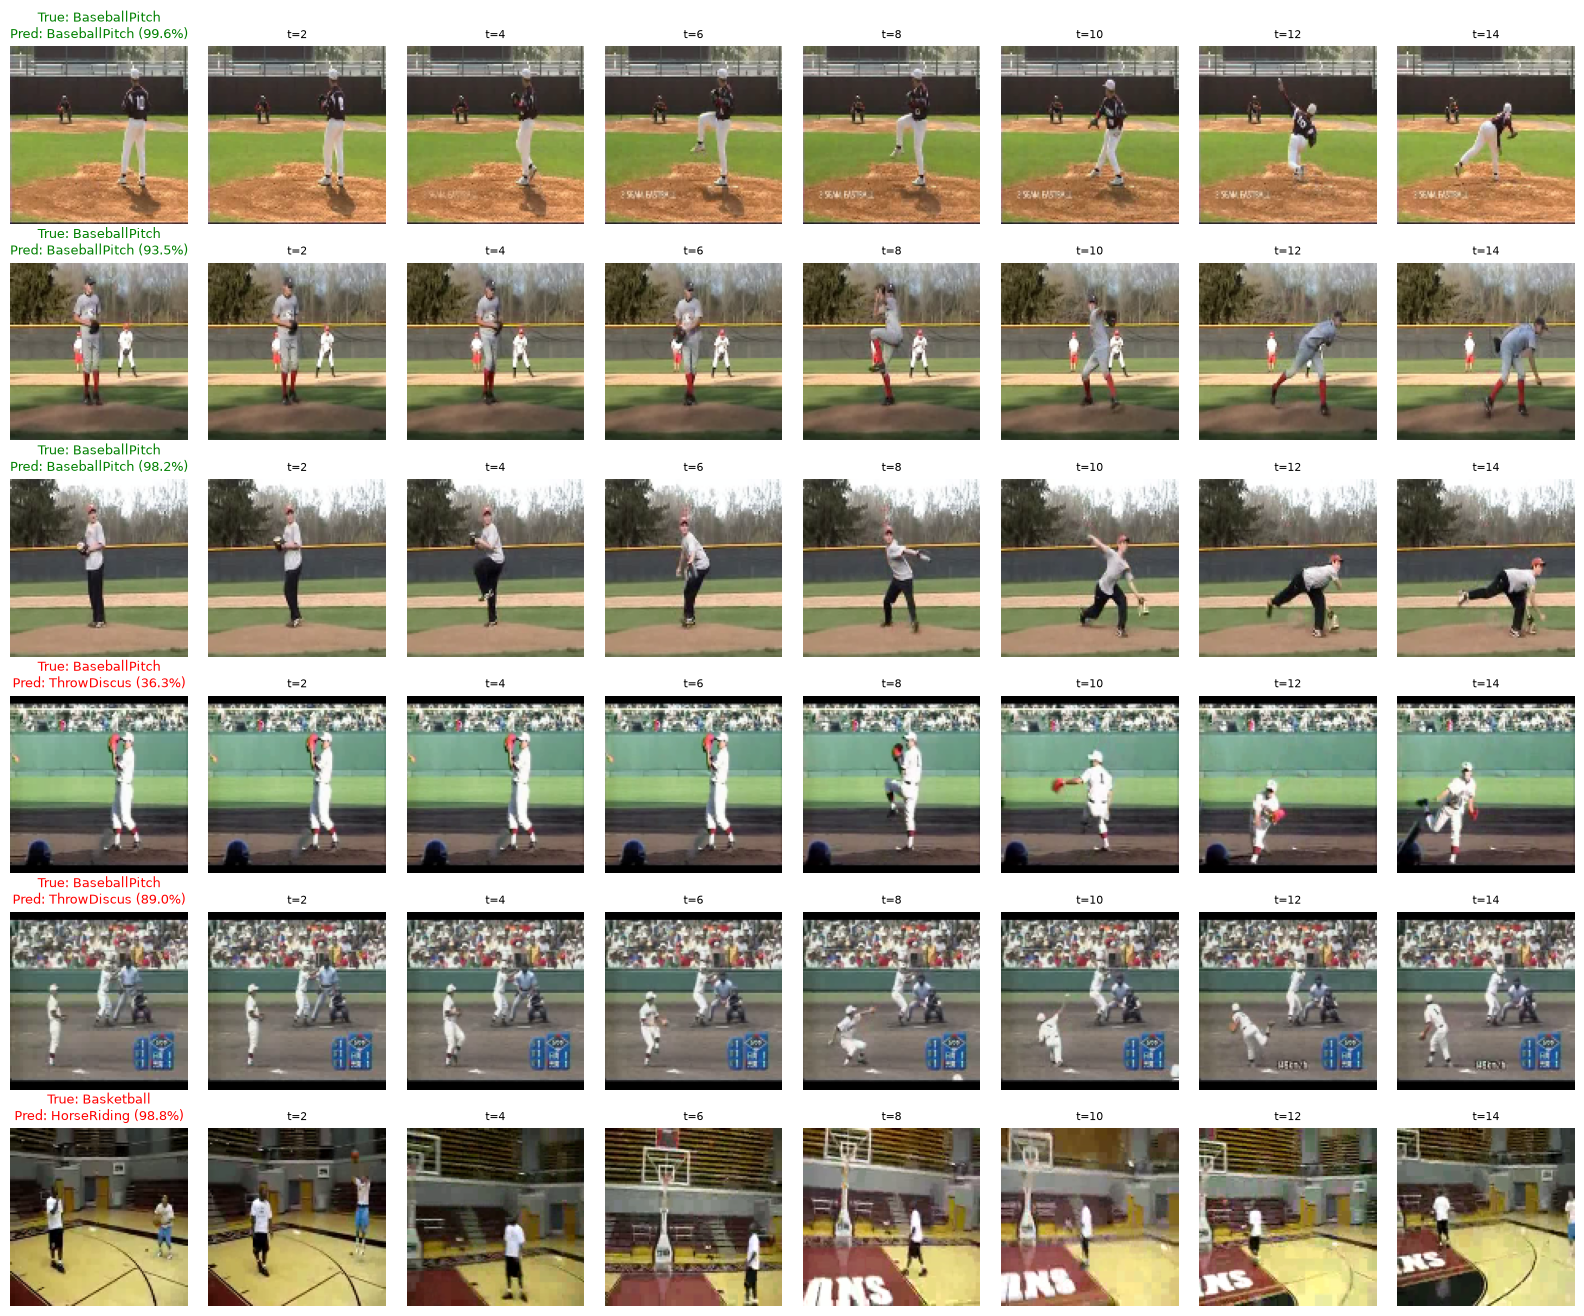

In [12]:
correct_indices = [i for i in range(len(val_loader.dataset)) if all_preds[i] == all_targets[i]][:3]
incorrect_indices = [i for i in range(len(val_loader.dataset)) if all_preds[i] != all_targets[i]][:3]
display_indices = correct_indices + incorrect_indices

mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
frame_steps = [0, 2, 4, 6, 8, 10, 12, 14]

fig, axes = plt.subplots(len(display_indices), len(frame_steps), figsize=(16, 2.2 * len(display_indices)))

for row, idx in enumerate(display_indices):
    x_val, y_val = val_loader.dataset[idx]
    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            logits = model(x_val.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)[0]

    pred_idx = torch.argmax(probs).item()
    conf = probs[pred_idx].item() * 100
    true_cls = class_names[y_val]
    pred_cls = class_names[pred_idx]
    is_correct = (pred_idx == y_val)
    status_color = "green" if is_correct else "red"

    for col, f_idx in enumerate(frame_steps):
        ax = axes[row, col]
        img = x_val[:, f_idx, :, :].cpu().numpy()
        img = (img * std + mean).transpose(1, 2, 0)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            title_text = f"True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)"
            ax.set_title(title_text, color=status_color, fontsize=9)
        else:
            ax.set_title(f"t={f_idx}", fontsize=8)

plt.tight_layout()
plt.show()


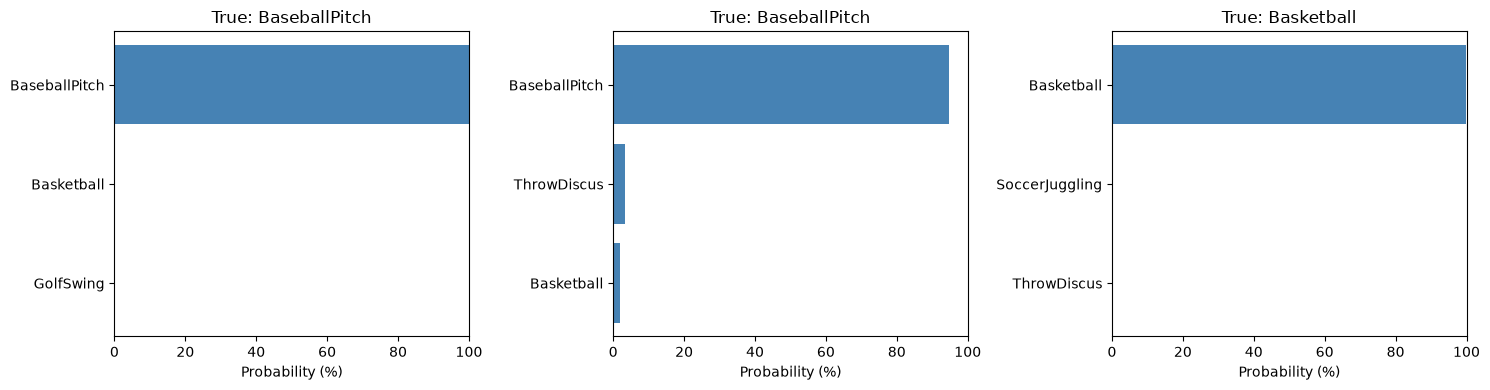

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
test_sample_indices = [5, 25, 45]

for i, s_idx in enumerate(test_sample_indices):
    x_val, y_val = val_loader.dataset[s_idx]
    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            logits = model(x_val.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)[0]
    
    top3_probs, top3_indices = torch.topk(probs, k=3)
    top3_probs = [p.item() * 100 for p in top3_probs]
    top3_names = [class_names[idx.item()] for idx in top3_indices]
    
    axes[i].barh(np.arange(3), top3_probs, color="steelblue")
    axes[i].set_yticks(np.arange(3))
    axes[i].set_yticklabels(top3_names)
    axes[i].set_xlabel("Probability (%)")
    axes[i].set_xlim(0, 100)
    axes[i].invert_yaxis()
    axes[i].set_title(f"True: {class_names[y_val]}")

plt.tight_layout()
plt.show()


**Nhận xét:**

Khi chuyển từ dạng song song sang kiến trúc tích chập nối tiếp tuần tự có chuẩn hóa lớp, mô hình hoạt động ổn định và hiệu quả hơn hẳn. Độ chính xác đạt mốc 81.4%, cao nhất trong ba mô hình 3D CNN tự xây dựng.

Cấu trúc nối tiếp giúp luồng truyền dữ liệu mượt mà hơn và hạn chế phân tán đặc trưng. Tốc độ suy luận của mô hình này cũng rất nhanh, cho thấy thiết kế tuần tự gọn gàng mang lại hiệu quả thực tế rất tốt so với thiết kế chia nhánh phức tạp.